# Model Predictions with Ultralytics YOLO
by MJRovai @ 22Jan2026

https://docs.ultralytics.com/modes/predict/

In [1]:
import time
import numpy as np
from PIL import Image
from ultralytics import YOLO
import matplotlib.pyplot as plt

In [3]:
!ls ./images

beatles.jpg  bus.jpg


In [4]:
!ls models

yolo11n.pt  yolov8n.pt


In [5]:
model_path= "./models/yolo11n.pt"
task = "detect" # Task: ‘detect’, ‘segment’, ‘classify’, ‘pose’, etc.
verbose = False # Verbose output during model initialization

In [6]:
# Load a pretrained YOLO11n model
model = YOLO(model_path, task, verbose)

In [7]:
# Open an image using PIL
source = Image.open("./images/bus.jpg")

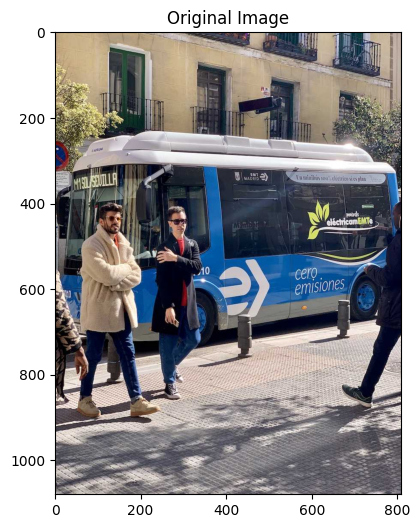

In [8]:
# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(source)
#plt.axis('off')  # This turns off the axis numbers
plt.title("Original Image")
plt.show()

In [9]:
# Run inference on the source
results = model.predict(source, save=False, imgsz=640, conf=0.5, iou=0.3)


0: 640x480 4 persons, 1 bus, 315.3ms
Speed: 6.7ms preprocess, 315.3ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 480)


In [10]:
# Run inference again on the source
results = model.predict(source, save=False, imgsz=640, conf=0.5, iou=0.3)


0: 640x480 4 persons, 1 bus, 314.6ms
Speed: 8.6ms preprocess, 314.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)


`Usually, the first time that an inference is run, the latency is greater. `

In [11]:
verbose = True
model = YOLO(model_path, task, verbose)

results = model.predict(source, save=False, imgsz=640, conf=0.5, iou=0.3)


0: 640x480 4 persons, 1 bus, 297.0ms
Speed: 6.8ms preprocess, 297.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)


`results` is a list. 

In [12]:
len(results)

1

In [13]:
result = results[0]
result

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant',

In [14]:
result.boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([5., 0., 0., 0., 0.])
conf: tensor([0.9402, 0.8882, 0.8783, 0.8558, 0.6219])
data: tensor([[3.8328e+00, 2.2936e+02, 7.9619e+02, 7.2841e+02, 9.4015e-01, 5.0000e+00],
        [6.7102e+02, 3.9483e+02, 8.0981e+02, 8.7871e+02, 8.8822e-01, 0.0000e+00],
        [4.7405e+01, 3.9957e+02, 2.3930e+02, 9.0420e+02, 8.7825e-01, 0.0000e+00],
        [2.2306e+02, 4.0869e+02, 3.4447e+02, 8.6044e+02, 8.5577e-01, 0.0000e+00],
        [2.1713e-02, 5.5607e+02, 6.8885e+01, 8.7236e+02, 6.2192e-01, 0.0000e+00]])
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([5, 6])
xywh: tensor([[400.0137, 478.8882, 792.3618, 499.0482],
        [740.4135, 636.7728, 138.7925, 483.8793],
        [143.3527, 651.8801, 191.8959, 504.6299],
        [283.7633, 634.5621, 121.4087, 451.7472],
        [ 34.4536, 714.2138,  68.8638, 316.2908]])
xywhn: tensor([[0.4938, 0.4434, 0.9782, 0.4621],
        [0.9141, 0.5896, 0.1713, 0.4480],
        [0.17

In [15]:
result.boxes.cls

tensor([5., 0., 0., 0., 0.])

In [16]:
result.names[0]

'person'

In [17]:
result.names[5]

'bus'

In [18]:
result.boxes.conf

tensor([0.9402, 0.8882, 0.8783, 0.8558, 0.6219])

In [19]:
result.boxes.data

tensor([[3.8328e+00, 2.2936e+02, 7.9619e+02, 7.2841e+02, 9.4015e-01, 5.0000e+00],
        [6.7102e+02, 3.9483e+02, 8.0981e+02, 8.7871e+02, 8.8822e-01, 0.0000e+00],
        [4.7405e+01, 3.9957e+02, 2.3930e+02, 9.0420e+02, 8.7825e-01, 0.0000e+00],
        [2.2306e+02, 4.0869e+02, 3.4447e+02, 8.6044e+02, 8.5577e-01, 0.0000e+00],
        [2.1713e-02, 5.5607e+02, 6.8885e+01, 8.7236e+02, 6.2192e-01, 0.0000e+00]])

**Geometric Attributes**
- xywh: Tensor with bounding box coordinates in center_x, center_y, width, height format, in pixels.
- xywhn: Normalized center_x, center_y, width, height, scaled to the image dimensions, values in .
- xyxy: Tensor of boxes as x1, y1, x2, y2 in pixels, representing the top-left and bottom-right corners.
- xyxyn: Normalized x1, y1, x2, y2, scaled by image width and height, values in .

In [20]:
result.boxes.xyxy

tensor([[3.8328e+00, 2.2936e+02, 7.9619e+02, 7.2841e+02],
        [6.7102e+02, 3.9483e+02, 8.0981e+02, 8.7871e+02],
        [4.7405e+01, 3.9957e+02, 2.3930e+02, 9.0420e+02],
        [2.2306e+02, 4.0869e+02, 3.4447e+02, 8.6044e+02],
        [2.1713e-02, 5.5607e+02, 6.8885e+01, 8.7236e+02]])

In [72]:
#result.show()  # display to screen

In [22]:
im_bgr = result.plot()
img = Image.fromarray(im_bgr[..., ::-1])

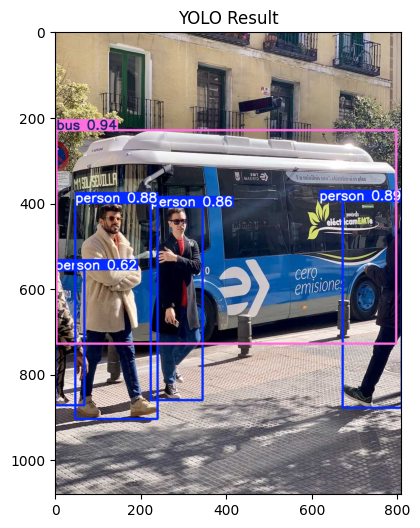

In [23]:
plt.figure(figsize=(6, 6))
plt.imshow(img)
#plt.axis('off')  # This turns off the axis numbers
plt.title("YOLO Result")
plt.show()

In [24]:
width, height = img.size
width, height

(810, 1080)

In [25]:
result.save(filename="bus_result.jpg")  # save to disk

'bus_result.jpg'

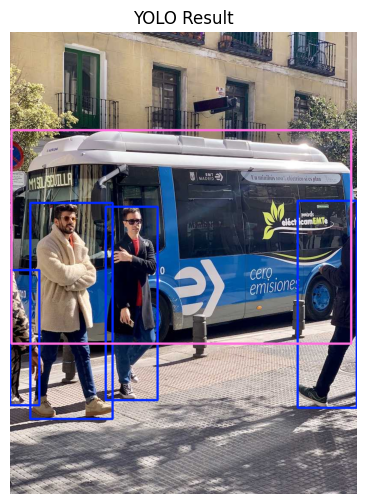

In [26]:
im_bgr = result.plot(boxes=True, labels=False, conf=False)
img = Image.fromarray(im_bgr[..., ::-1])

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')  # This turns off the axis numbers
plt.title("YOLO Result")
plt.show()

In [27]:
ls ./images/

beatles.jpg  bus.jpg


In [28]:
source = Image.open("./images/beatles.jpg")

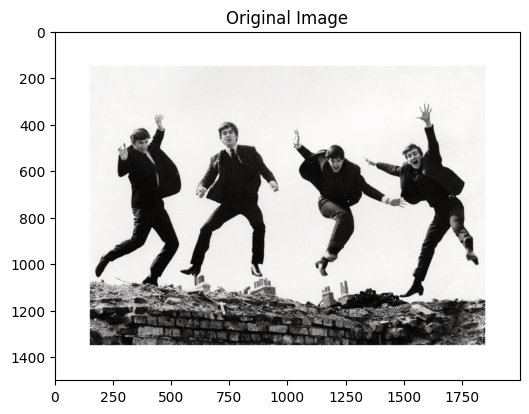

In [29]:
# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(source)
#plt.axis('off')  # This turns off the axis numbers
plt.title("Original Image")
plt.show()

In [30]:
results = model.predict(source, save=False, imgsz=640, conf=0.5, iou=0.3)
result = results[0]


0: 480x640 4 persons, 304.5ms
Speed: 6.9ms preprocess, 304.5ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)


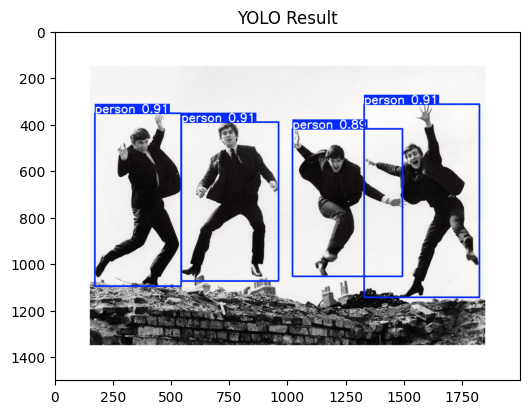

In [31]:
im_bgr = result.plot()
img = Image.fromarray(im_bgr[..., ::-1])
plt.figure(figsize=(6, 6))
plt.imshow(img)
#plt.axis('off')  # This turns off the axis numbers
plt.title("YOLO Result")
plt.show()

The plot() method in Ultralytics YOLO Results object accepts several arguments to control what is visualized on the image, including boxes, masks, keypoints, confidences, labels, and more.
Common Arguments for plot()
- boxes (bool): Show/hide bounding boxes. Default is True.
- conf (bool): Show/hide confidence scores. Default is True.
- labels (bool): Show/hide class labels. Default is True.
- masks (bool): Show/hide segmentation masks (when available, e.g. in segment tasks).
- kpt_line (bool): Draw lines connecting pose keypoints (skeleton diagram). Default is True in pose tasks.
- line_width (int): Set annotation line thickness.
- font_size (int): Set font size for text annotations.
- show (bool): If True, immediately display the image (interactive environments).

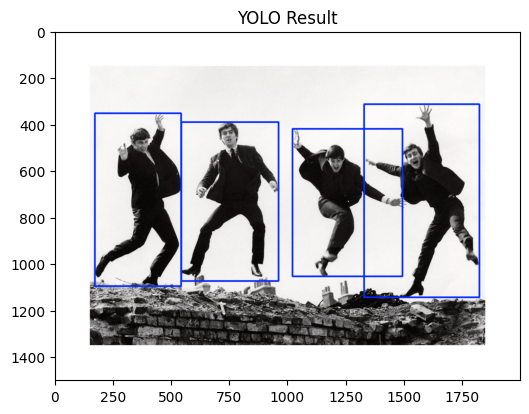

In [32]:
im_bgr = result.plot(boxes=True, labels=False, conf=False)
img = Image.fromarray(im_bgr[..., ::-1])
plt.figure(figsize=(6, 6))
plt.imshow(img)
#plt.axis('off')  # This turns off the axis numbers
plt.title("YOLO Result")
plt.show()

## Testing with other tasks

### Instance Segmentation

In [33]:
model_path= "./models/yolo11n-seg.pt"
task = "segment"
verbose = True

In [34]:
# Load a pretrained YOLO11n model
model = YOLO(model_path, task, verbose)

In [35]:
source = Image.open("./images/bus.jpg")

In [36]:
results = model.predict(source, save=False)
result = results[0]


0: 640x480 4 persons, 1 bus, 1 stop sign, 433.0ms
Speed: 6.2ms preprocess, 433.0ms inference, 13.7ms postprocess per image at shape (1, 3, 640, 480)


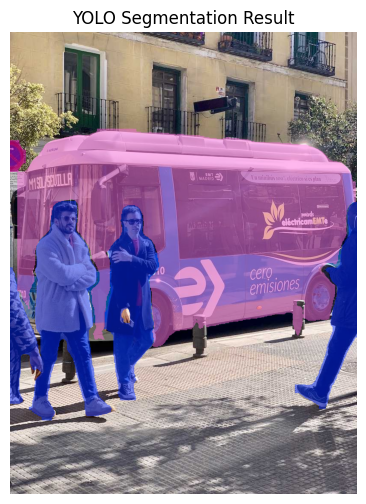

In [37]:
im_bgr = result.plot(boxes=False, conf=False, masks=True)
img = Image.fromarray(im_bgr[..., ::-1])
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')  # This turns off the axis numbers
plt.title("YOLO Segmentation Result")
plt.show()

In [38]:
source = Image.open("./images/beatles.jpg")

In [39]:
results = model.predict(source, save=False)
result = results[0]


0: 480x640 4 persons, 419.1ms
Speed: 9.3ms preprocess, 419.1ms inference, 6.6ms postprocess per image at shape (1, 3, 480, 640)


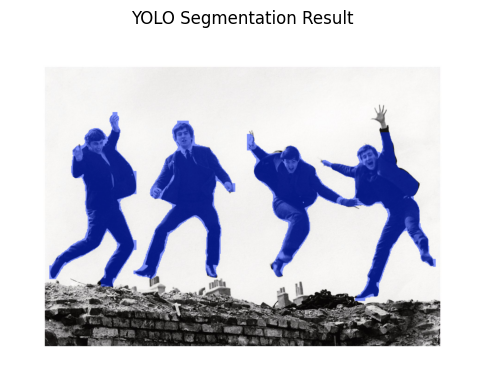

In [40]:
im_bgr = result.plot(boxes=False, conf=False, masks=True)
img = Image.fromarray(im_bgr[..., ::-1])
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')  # This turns off the axis numbers
plt.title("YOLO Segmentation Result")
plt.show()

### Pose Estimation

In [41]:
model_path= "./models/yolo11n-pose.pt"
task = "pose"
verbose = True

In [42]:
# Load a pretrained YOLO11n model
model = YOLO(model_path, task, verbose)

In [43]:
source = Image.open("./images/bus.jpg")

In [44]:
results = model.predict(source, save=False)
result = results[0]


0: 640x480 4 persons, 334.0ms
Speed: 6.6ms preprocess, 334.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)


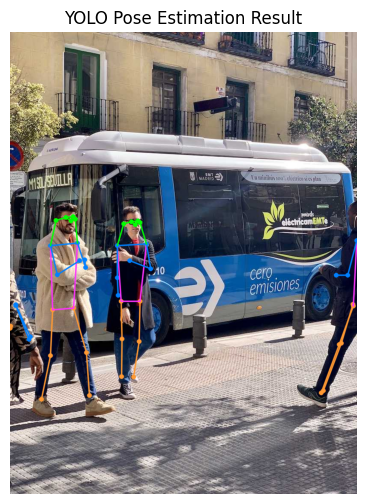

In [45]:
im_bgr = result.plot(boxes=False, conf=False, kpt_line=True)
img = Image.fromarray(im_bgr[..., ::-1])
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')  # This turns off the axis numbers
plt.title("YOLO Pose Estimation Result")
plt.show()

In [46]:
source = Image.open("./images/beatles.jpg")
results = model.predict(source, save=False)
result = results[0]


0: 480x640 4 persons, 329.2ms
Speed: 9.7ms preprocess, 329.2ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)


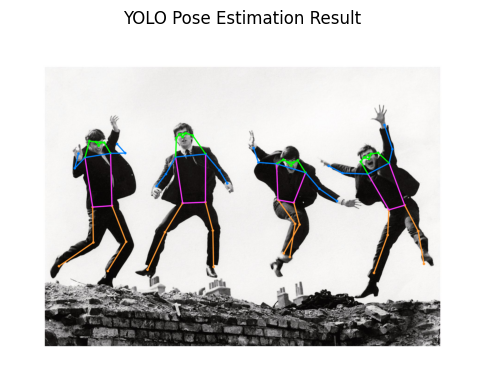

In [47]:
im_bgr = result.plot(boxes=False, conf=False, kpt_line=True)
img = Image.fromarray(im_bgr[..., ::-1])
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')  # This turns off the axis numbers
plt.title("YOLO Pose Estimation Result")
plt.show()

## Inference With The Trained Model

In [48]:
!ls ./models

box_wheel_320_yolo.pt  yolo11n-pose.pt	yolo11n.pt  yolo11n-seg.pt  yolov8n.pt


In [49]:
model_path= "./models/box_wheel_320_yolo.pt"
task = "detect" 
verbose = True

In [50]:
# Load a pretrained YOLO11n model with a customized dataset
model = YOLO(model_path, task, verbose)

In [51]:
!ls ./images

1_box_1_wheel.jpg  2_wheel.jpg	box_1.jpg	   box_2_wheel_2.jpg  bus.jpg
1_wheel.jpg	   beatles.jpg	box_2_wheel_1.jpg  box_3_wheel_4.jpg


In [52]:
# Open an image using PIL
source = Image.open("./images/box_1.jpg")

In [53]:
# Run inference on the source
results = model.predict(source, save=False, imgsz=640, conf=0.5, iou=0.3)


0: 640x640 1 box, 411.6ms
Speed: 4.0ms preprocess, 411.6ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


In [54]:
result = results[0]

In [55]:
result.boxes.cls

tensor([0.])

In [56]:
result.names

{0: 'box', 1: 'wheel'}

In [57]:
result.boxes.conf

tensor([0.8396])

In [58]:
result.boxes.xyxy

tensor([[169.2160,  74.4991, 395.6134, 384.3987]])

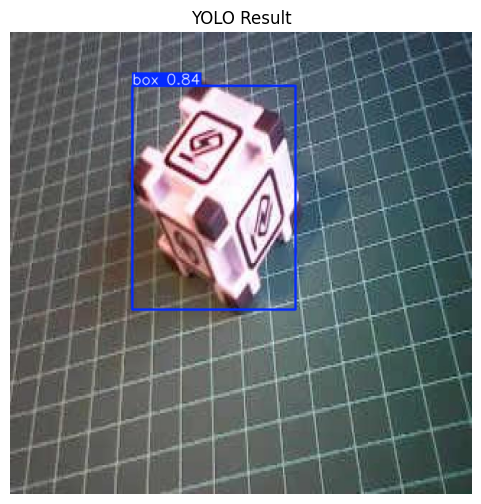

In [59]:
im_bgr = result.plot()
img = Image.fromarray(im_bgr[..., ::-1])

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')  # This turns off the axis numbers
plt.title("YOLO Result")
plt.show()

### Creating a function

In [60]:
def infer_yolo(source, conf=0.5, iou=0.3):
    results = model.predict(source, save=False, imgsz=640, conf=conf, iou=iou)
    result = results[0]

    im_bgr = result.plot()
    img = Image.fromarray(im_bgr[..., ::-1])

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')  # This turns off the axis numbers
    plt.title("YOLO Result")
    plt.show()

In [61]:
!ls ./images

1_box_1_wheel.jpg  2_wheel.jpg	box_1.jpg	   box_2_wheel_2.jpg  bus.jpg
1_wheel.jpg	   beatles.jpg	box_2_wheel_1.jpg  box_3_wheel_4.jpg



image 1/1 /home/mjrovai/Documents/YOLO/images/box_2_wheel_1.jpg: 480x640 2 boxs, 1 wheel, 309.6ms
Speed: 7.6ms preprocess, 309.6ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)


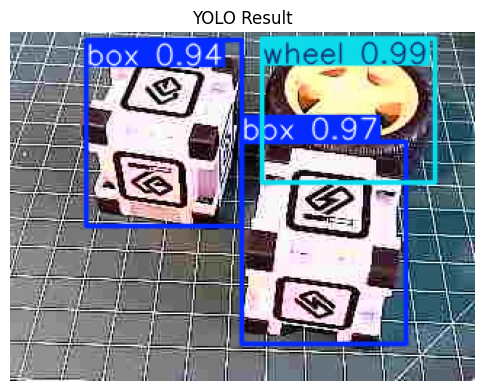

In [62]:
infer_yolo("./images/box_2_wheel_1.jpg")


image 1/1 /home/mjrovai/Documents/YOLO/images/box_2_wheel_2.jpg: 640x640 2 boxs, 2 wheels, 424.5ms
Speed: 5.1ms preprocess, 424.5ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


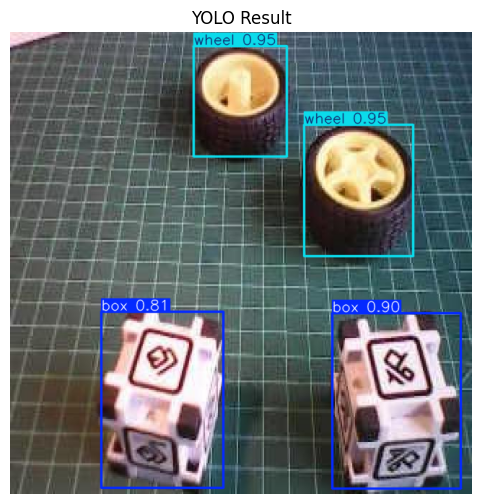

In [63]:
infer_yolo("./images/box_2_wheel_2.jpg")


image 1/1 /home/mjrovai/Documents/YOLO/images/box_3_wheel_4.jpg: 640x640 3 boxs, 4 wheels, 414.1ms
Speed: 3.2ms preprocess, 414.1ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


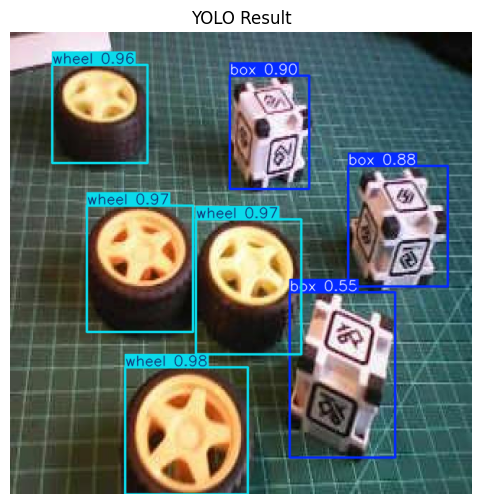

In [64]:
infer_yolo("./images/box_3_wheel_4.jpg")

### Exporting the model 

In [ ]:
# Run this command on Terminal: $ yolo export model=./models/box_wheel_320_yolo.pt format=ncnn imgsz=320

In [66]:
!ls ./models

box_wheel_320_yolo_ncnn_model  yolo11n-pose.pt	yolo11n-seg.pt
box_wheel_320_yolo.pt	       yolo11n.pt	yolov8n.pt


In [67]:
model_path= "./models/box_wheel_320_yolo_ncnn_model "
task = "detect" 
verbose = True

In [68]:
# Load the converted ncnn model with a customized dataset
model = YOLO(model_path, task, verbose)

Loading ./models/box_wheel_320_yolo_ncnn_model for NCNN inference...

image 1/1 /home/mjrovai/Documents/YOLO/images/box_3_wheel_4.jpg: 640x640 3 boxs, 4 wheels, 79.4ms
Speed: 3.7ms preprocess, 79.4ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


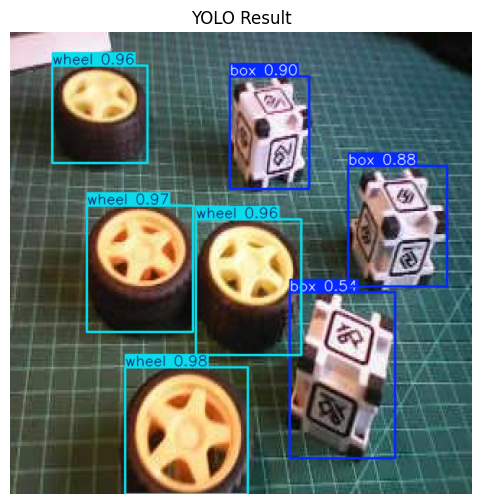

In [69]:
infer_yolo("./images/box_3_wheel_4.jpg")


image 1/1 /home/mjrovai/Documents/YOLO/images/box_1.jpg: 640x640 1 box, 102.3ms
Speed: 3.6ms preprocess, 102.3ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


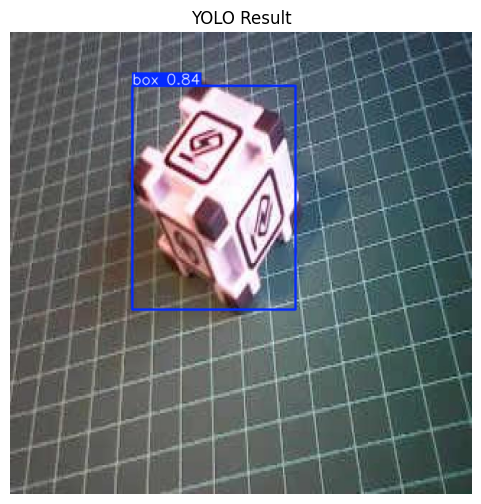

In [70]:
infer_yolo("./images/box_1.jpg")


image 1/1 /home/mjrovai/Documents/YOLO/images/box_2_wheel_2.jpg: 640x640 2 boxs, 2 wheels, 78.1ms
Speed: 5.2ms preprocess, 78.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


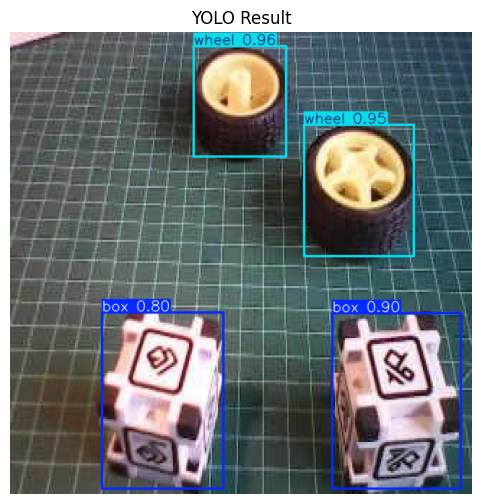

In [71]:
infer_yolo("./images/box_2_wheel_2.jpg")